# Clustering stability analysis

This notebook performs a clustering stability analysis to quantify how stable
PLSCAN's clustering is on samples of the same underlying dataset. The
methodology is adapted from [Ben-Hur et al.,
2002](https://pages.cs.wisc.edu/~nathanae/cdistrefs/benhur__subsampling_and_jaccard.pdf),
who use the similarity between clusterings of subsamples of a dataset as a
measure of stability.

First, lets load the required dependencies.

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

from hdbscan import HDBSCAN
from fast_plscan import PLSCAN

from lib.plotting import sns, plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (2.75, 0.618 * 2.75)

Next, we'll use the pre-processed data from the sensitivity benchmark:

In [2]:
prefix = "benchmark_sensitivity_"
suffix = "_features.npy"
offset = len("data/generated/") + len(prefix)
preprocessed_data_files = [
    f"data/generated/{file}"
    for file in os.listdir("data/generated")
    if file.startswith(prefix) and file.endswith(suffix)
]
dataset_names = [file[offset : -len(suffix)] for file in preprocessed_data_files]

# List number of classes for k-means
num_classes = {
    "articles_1442_5": 5,
    "articles_1442_80": 5,
    "audioset": 51,
    "authorship": 4,
    "cardiotocography": 10,
    "cell_cycle_237": 5,
    "cifar_10": 10,
    "ecoli": 7,
    "elegans": 26,
    "fashion_mnist": 9,
    "iris": 2,
    "mfeat_factors": 10,
    "mfeat_karhunen": 10,
    "mnist": 9,
    "newsgroups": 19,
    "semeion": 10,
    "yeast_galactose": 4,
}

Now, we'll configure the algorithms

In [3]:
alg_ids = [
    "hdbscan_eom",
    "hdbscan_leaf",
    "plscan_size",
    "plscan_distance",
    "plscan_density",
    "plscan_size-distance",
    "plscan_size-density",
    "kmeans_random",
    "kmeans_++"
]
algorithms = [
    HDBSCAN(min_samples=4, min_cluster_size=4, cluster_selection_method="eom"),
    HDBSCAN(min_samples=4, min_cluster_size=4, cluster_selection_method="leaf"),
    PLSCAN(min_samples=4, min_cluster_size=4, persistence_measure="size"),
    PLSCAN(min_samples=4, min_cluster_size=4, persistence_measure="distance"),
    PLSCAN(min_samples=4, min_cluster_size=4, persistence_measure="density"),
    PLSCAN(min_samples=4, min_cluster_size=4, persistence_measure="size-distance"),
    PLSCAN(min_samples=4, min_cluster_size=4, persistence_measure="size-density"),
    KMeans(init="random", n_init=1),
    KMeans(n_init=1)
]

Now, we'll loop over the datasets and algorithms, repeatedly take two samples
with 80% of the dataset, and record the ARI across points in both samples.

In [4]:
repeats = 15
sample_ratio = 0.8

results = []
total = len(dataset_names) * len(algorithms) * repeats
pbar = tqdm(total=total)
for dataset_name, data_file in zip(dataset_names, preprocessed_data_files):
    X = np.load(data_file).astype(np.float32)
    sample_size = int(sample_ratio * X.shape[0])
    labels_1 = np.zeros(X.shape[0], dtype=int)
    labels_2 = np.zeros(X.shape[0], dtype=int)
    for repeat in range(repeats):
        sample_1 = np.random.choice(X.shape[0], sample_size, replace=False)
        sample_2 = np.random.choice(X.shape[0], sample_size, replace=False)
        intercept = np.intersect1d(sample_1, sample_2)
        for alg_id, Alg in zip(alg_ids, algorithms):
            if alg_id == "kmeans":
                Alg.set_params(n_clusters=num_classes[dataset_name])
            labels_1[sample_1] = Alg.fit_predict(X[sample_1])
            labels_2[sample_2] = Alg.fit_predict(X[sample_2])
            ari = adjusted_rand_score(labels_1[intercept], labels_2[intercept])
            results.append(
                {
                    "dataset": dataset_name,
                    "alg_id": alg_id,
                    "repeat": repeat,
                    "ari": ari,
                }
            )
            pbar.update()
            pbar.set_postfix(
                {"dataset": dataset_name, "repeat": repeat, "alg_id": alg_id}
            )
pbar.close()

results_df = pd.DataFrame(results)
results_df.to_parquet("data/generated/clustering_stability_results.parquet")

100%|██████████| 2295/2295 [17:32<00:00,  2.18it/s, dataset=yeast_galactose, repeat=14, alg_id=kmeans_++]            


We plot the results per dataset below. The stability of the algorithms differs
considerably between the datasets.

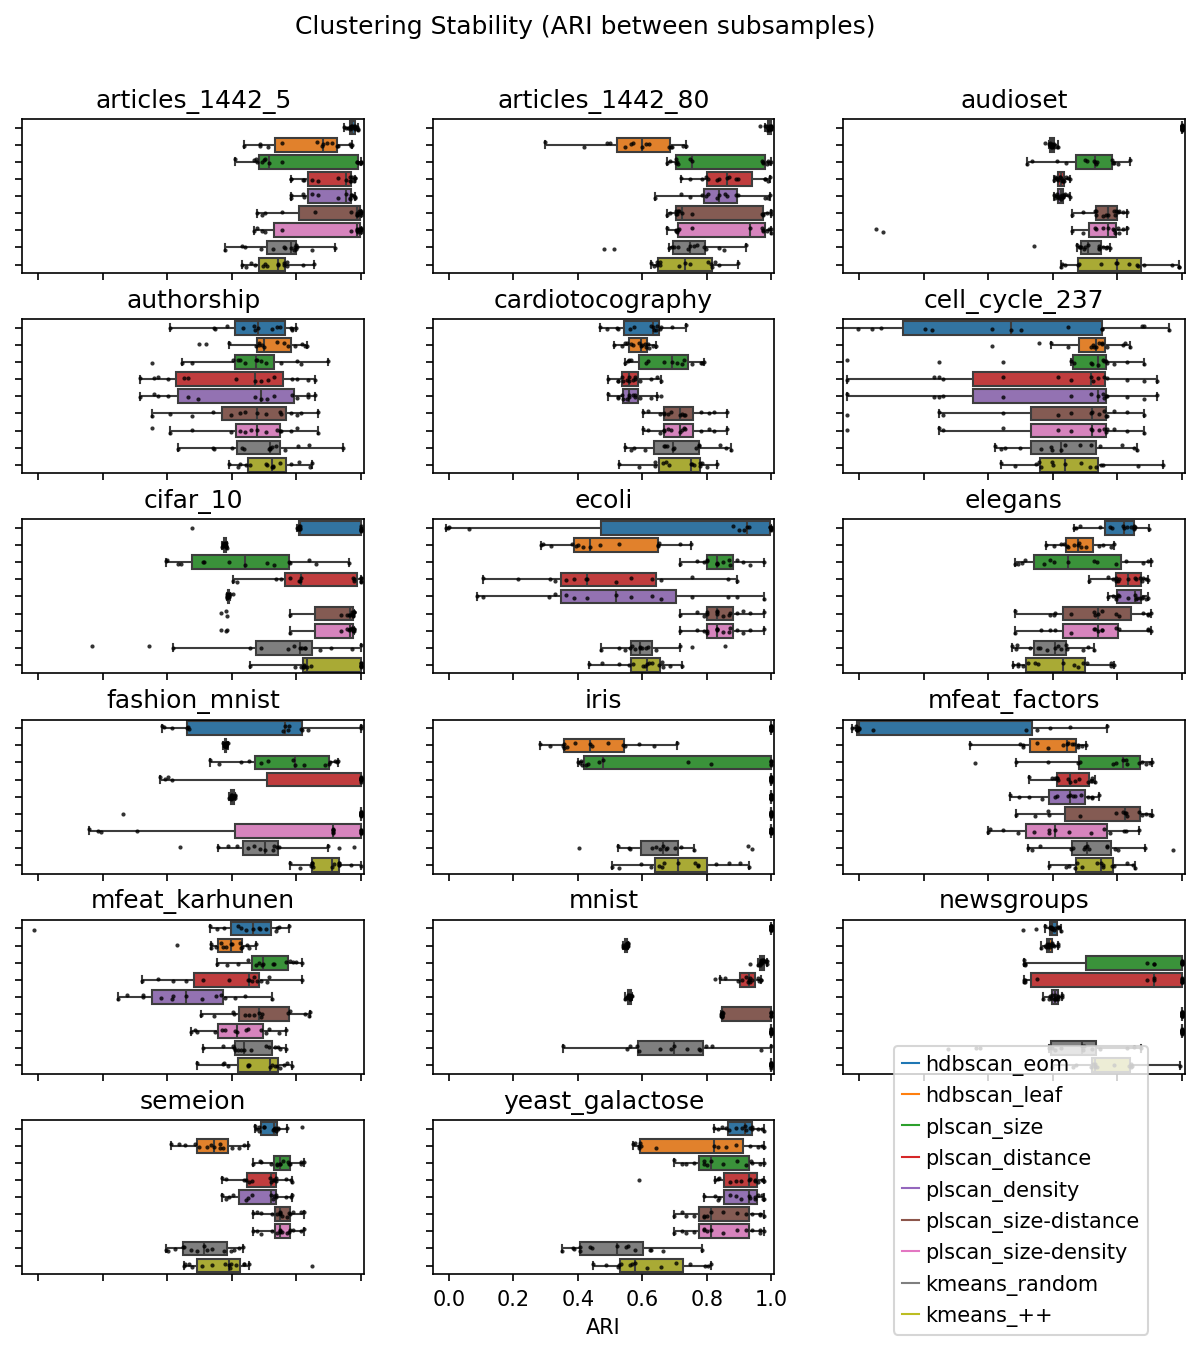

In [5]:
palette = plt.get_cmap("tab10").colors

plt.figure(figsize=(10, 10))
for i, dataset in enumerate(dataset_names):
    plt.subplot(6, 3, i + 1)
    sub_df = results_df.query("dataset == @dataset")
    sns.boxplot(
        data=sub_df,
        x="ari",
        y="alg_id",
        hue="alg_id",
        hue_order=alg_ids,
        order=alg_ids,
        palette=palette,
        legend=False,
        fliersize=0,
    )
    sns.stripplot(
        data=sub_df,
        x="ari",
        y="alg_id",
        order=alg_ids,
        legend=False,
        color="black",
        size=2,
        alpha=0.8,
        jitter=0.15,
    )
    plt.ylabel("")
    plt.title(dataset)
    plt.gca().set_yticklabels([])
    plt.xlim(-0.05, 1.01)
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.xlabel("" if i < len(dataset_names) - 1 else "ARI")
    if i < len(dataset_names) - 1:
        plt.gca().set_xticklabels([])

plt.subplot(9, 2, 18)
plt.axis("off")
plt.legend(
    handles=[
        plt.Line2D([0], [0], color=palette[j], lw=1, label=n)
        for j, n in enumerate(alg_ids)
    ],
    loc="lower right",
    bbox_to_anchor=(0.95, -0.7),
    handlelength=0.8,
    columnspacing=0.6,
    handletextpad=0.3,
)
plt.suptitle("Clustering Stability (ARI between subsamples)", y=0.95)
plt.subplots_adjust(hspace=0.3)
plt.show()

Aggregated per algorithm:

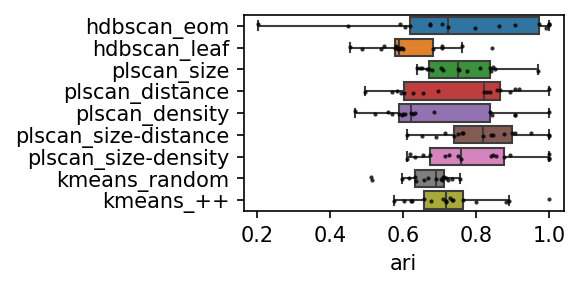

In [6]:
plot_df = results_df.groupby(["dataset", "alg_id"])["ari"].agg("mean").reset_index()
sns.boxplot(
    data=plot_df,
    x="ari",
    y="alg_id",
    hue="alg_id",
    hue_order=alg_ids,
    order=alg_ids,
    palette=palette,
    legend=False,
    fliersize=0,
)
sns.stripplot(
    data=plot_df,
    x="ari",
    y="alg_id",
    order=alg_ids,
    legend=False,
    color="black",
    size=2,
    alpha=0.8,
)
plt.ylabel("")
plt.show()